## Auotmated sleep stagging from YASA

In [1]:
import mne
import yasa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)
print('The channels are:', raw.ch_names)
print('The sampling frequency is:', raw.info['sfreq'])
raw

Extracting EDF parameters from D:\EEG\raw\MN143\MN143_240115E-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 6855679  =      0.000 ... 26779.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_20440\2454404324.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf('D:/EEG/raw/MN143/MN143_240115E-A.edf', preload=True)


The channels are: ['EEG Fp1', 'EEG Fp2', 'EEG C3', 'EEG C4', 'EEG T3', 'EEG T4', 'EEG O1', 'EEG O2', 'EOGD', 'EOGG', 'EEG A1', 'Menton', 'VTH', 'VAB', 'THERM', 'NAF2P', 'RONF', 'ECG', 'SAT', 'POS', 'PTT', 'PCO2', 'FC', 'Pouls', 'JAMBG', 'JAMBD', 'EMG2', 'EMG1', 'EEG Cz', 'EEG Pz', 'SPo2_Cap', 'SLI', 'CPAP']
The sampling frequency is: 256.0


<RawEDF | MN143_240115E-A.edf, 33 x 6855680 (26780.0 s), ~1.69 GiB, data loaded>

In [3]:
# Let's now load the human-scored hypnogram, where each value represents a 30-sec epoch.
hyp_filepath = 'D:/EEG/raw/MN143/MN143_240115E-AhypnoEXP.txt'
hyp = pd.read_csv(hyp_filepath, sep="\t", names=["start", "time", "stage", "code"])
hyp = hyp[["start", "stage"]]
hyp

,start,stage
0,30,W
1,60,W
2,90,W
3,120,W
4,150,W
...,...,...
887,26640,W
888,26670,W
889,26700,W
890,26730,W


In [4]:
# Convert it to a Hypnogram instance, which is the preferred way to manipulate hypnograms since v0.7
stages = hyp["stage"].str.upper().str.strip()
hyp = yasa.Hypnogram(stages, freq="30s")
# The hypnogram values can be obtained with
hyp.hypno

Epoch
0      WAKE
1      WAKE
2      WAKE
3      WAKE
4      WAKE
       ... 
887    WAKE
888    WAKE
889    WAKE
890    WAKE
891    WAKE
Name: Stage, Length: 892, dtype: category
Categories (7, object): ['WAKE', 'N1', 'N2', 'N3', 'REM', 'ART', 'UNS']

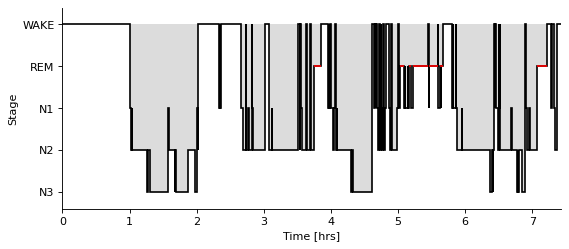

In [5]:
# Let's plot it
fig, ax = plt.subplots(1, 1, figsize=(7, 3), constrained_layout=True, dpi=80)
ax = hyp.plot_hypnogram(fill_color="gainsboro", ax=ax)

In [6]:
# We first need to specify the channel names and, optionally, the age and sex of the participant
# - "raw" is the name of the variable containing the polysomnography data loaded with MNE.
# - "eeg_name" is the name of the EEG channel, preferentially a central derivation (e.g. C4-M1). This is always required to run the sleep staging algorithm.
# - "eog_name" is the name of the EOG channel (e.g. LOC-M1). This is optional.
# - "eog_name" is the name of the EOG channel (e.g. EMG1-EMG3). This is optional.
# - "metadata" is a dictionary containing the age and sex of the participant. This is optional.
sls = yasa.SleepStaging(raw, eeg_name="EEG C4", eog_name="EOGD", emg_name="Menton")
sls

In [7]:
# Getting the predicted sleep stages is now as easy as:
y_pred = sls.predict()
y_pred

c:\Users\Dessalines\Desktop\Cerco_studies\.venv_eegs\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 0.24.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


array(['W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W',
       'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'N1', 'N1', 'N1',
       'N1', 'N1', 'N1', 'N2', 'N1', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2',
       'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2',
       'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2',
       'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N2', 'N

In [8]:
hypno_pred = yasa.Hypnogram(y_pred, freq="30s")

hypno_pred.hypno

Epoch
0      WAKE
1      WAKE
2      WAKE
3      WAKE
4      WAKE
       ... 
887    WAKE
888    WAKE
889    WAKE
890    WAKE
891      N1
Name: Stage, Length: 892, dtype: category
Categories (7, object): ['WAKE', 'N1', 'N2', 'N3', 'REM', 'ART', 'UNS']

In [9]:
# What is the accuracy of the prediction, compared to the human scoring
accuracy = 100 * (hyp.hypno == hypno_pred.hypno).mean()
print(f"The overall agreement is {accuracy:.2f}%")

The overall agreement is 70.29%


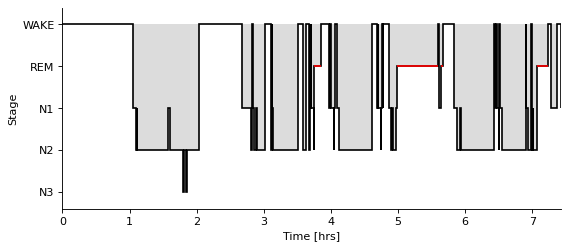

In [10]:
# Plot the predicted hypnogram
fig, ax = plt.subplots(1, 1, figsize=(7, 3), constrained_layout=True, dpi=80)
ax = hypno_pred.plot_hypnogram(fill_color="gainsboro", ax=ax)

In [11]:
# Calculate the summary sleep statistics of the predicted hypnogram
hypno_pred.sleep_statistics()

{'TIB': np.float64(446.0),
 'SPT': np.float64(383.0),
 'WASO': np.float64(90.5),
 'TST': np.float64(292.5),
 'SE': np.float64(65.583),
 'SME': np.float64(76.3708),
 'SFI': np.float64(2.4615),
 'SOL': np.float64(63.0),
 'SOL_5min': np.float64(63.0),
 'Lat_REM': np.float64(225.0),
 'WAKE': np.float64(153.5),
 'N1': np.float64(50.5),
 'N2': np.float64(185.0),
 'N3': np.float64(1.0),
 'REM': np.float64(56.0),
 '%N1': np.float64(17.265),
 '%N2': np.float64(63.2479),
 '%N3': np.float64(0.3419),
 '%REM': np.float64(19.1453)}

In [12]:
hypno_pred

<Hypnogram | 892 epochs x 30s (446.00 minutes), 5 stages>
 - Use `.hypno` to get the string values as a pandas.Series
 - Use `.as_int()` to get the integer values as a pandas.Series
 - Use `.plot_hypnogram()` to plot the hypnogram
See the online documentation for more details.

In [13]:
# What are the predicted probabilities of each sleep stage at each epoch?
sls.predict_proba()

,N1,N2,N3,R,W
epoch,,,,,
0,0.000012,0.000003,0.000002,1.797044e-07,0.999983
1,0.000583,0.000502,0.000013,4.075699e-05,0.998861
2,0.000971,0.000281,0.000011,6.158437e-06,0.998731
3,0.000820,0.000140,0.000070,6.618169e-06,0.998963
4,0.001235,0.000464,0.000053,2.010517e-05,0.998228
...,...,...,...,...,...
887,0.022986,0.003766,0.000136,2.920512e-03,0.970191
888,0.239007,0.004399,0.000041,1.203319e-02,0.744520
889,0.402011,0.013253,0.000031,2.265061e-02,0.562055


In [17]:
# What is the probability to be well classified ?
counts, probs = yasa.transition_matrix(hypno_pred.as_int())
probs.round(3)


To Stage,0,1,2,3,4
From Stage,,,,,
0,0.919,0.072,0.007,0.000,0.003
1,0.090,0.680,0.210,0.000,0.020
2,0.030,0.027,0.932,0.005,0.005
3,0.000,0.000,1.000,0.000,0.000
4,0.036,0.009,0.000,0.000,0.955


<Axes: xlabel='Time (30-sec epoch)', ylabel='Probability'>

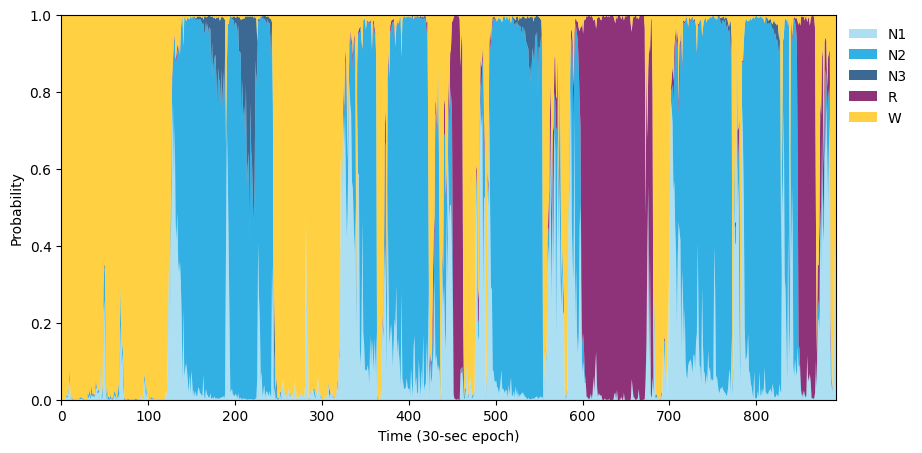

In [15]:
# Plot the predicted probabilities
sls.plot_predict_proba()

In [16]:
# From the probabilities, we can extract a confidence level (ranging from 0 to 1) for each epoch.
confidence = sls.predict_proba().max(1)
confidence

epoch
0      0.999983
1      0.998861
2      0.998731
3      0.998963
4      0.998228
         ...   
887    0.970191
888    0.744520
889    0.562055
890    0.954762
891    0.497685
Length: 892, dtype: float64

# On renomme les fichiers correctement

### .edf

In [ ]:
import pathlib

root_raw = pathlib.Path(r"D:\\EEG\\raw")
edf_paths = list(root_raw.rglob("*.edf"))
print(f"{len(edf_paths)} fichiers .edf trouvés.")

for i, path in enumerate(edf_paths):
    parent_name = path.parent.name
    new_name = f"{parent_name}_raw.edf"
    new_path = path.with_name(new_name)
    
    try:
        path.rename(new_path)
        print(f"Renommé : {path.name} -> {new_name}")
    except Exception as e:
        print(f"Erreur lors du renommage de {path.name} : {e}")


72 fichiers .edf trouvés.
Renommé : AE129_231121C-A.edf -> AE129_raw.edf
Renommé : 240425C-A.edf -> AN166_raw.edf
Renommé : 231024E-B.edf -> BA152_raw.edf
Renommé : 240822E-A.edf -> BA171_raw.edf
Renommé : 230426e-a.edf -> BB114_raw.edf
Renommé : 240925E-B.edf -> BF181_raw.edf
Renommé : 231024d-a.edf -> BJ138_raw.edf
Renommé : boyer olivier.edf -> BO60_raw.edf
Renommé : 240930D-A.edf -> CA169_raw.edf
Renommé : 240522E-A.edf -> CB165_raw.edf
Renommé : 241021D-A.edf -> CC175_raw.edf
Renommé : 240502D-A.edf -> CD164_raw.edf
Renommé : CD28.edf -> CD28_raw.edf
Renommé : castres jean pierre.edf -> CJP53_raw.edf
Renommé : 240306D-A.edf -> CM161_raw.edf
Renommé : 240521C-A.edf -> CP155_raw.edf
Renommé : 231130B-B.edf -> CS131_raw.edf
Renommé : CS147_240301e-a.edf -> CS147_raw.edf
Renommé : 230413c-b.edf -> DA110_raw.edf
Renommé : 240909A-B.edf -> DA174_raw.edf
Renommé : 230929B-B.edf -> DI136_raw.edf
Renommé : 231114c-b.edf -> DJ137_raw.edf
Renommé : 230614e-a.edf -> DSJ112_raw.edf
Renommé : 2

### .txt (hypno)

In [5]:
root_raw = pathlib.Path(r"D:\\EEG\\raw")
edf_paths = list(root_raw.rglob("*.txt"))
print(f"{len(edf_paths)} fichiers .edf trouvés.")

for i, path in enumerate(edf_paths):
    parent_name = path.parent.name
    new_name_hypno = f"{parent_name}_hypnoEXP.txt"
    new_path_hypno = path.with_name(new_name_hypno)

    try:
        path.rename(new_path_hypno)
        print(f"Renommé : {path.name} -> {new_name_hypno}")
    except Exception as e:
        print(f"Erreur lors du renommage de {path.name} : {e}")

68 fichiers .edf trouvés.
Renommé : AE129_231121C-AhypnoEXP.txt -> AE129_hypnoEXP.txt
Renommé : 240425C-AhypnoEXP.txt -> AN166_hypnoEXP.txt
Renommé : 231024E-BhypnoEXP.txt -> BA152_hypnoEXP.txt
Renommé : 240822E-AhypnoEXP.txt -> BA171_hypnoEXP.txt
Renommé : 230426e-ahypnoEXP.txt -> BB114_hypnoEXP.txt
Renommé : 240925E-BhypnoEXP.txt -> BF181_hypnoEXP.txt
Renommé : 231024d-ahypnoEXP.txt -> BJ138_hypnoEXP.txt
Renommé : boyer olivierhypnoEXP.txt -> BO60_hypnoEXP.txt
Renommé : 240930D-AhypnoEXP.txt -> CA169_hypnoEXP.txt
Renommé : 240522E-AhypnoEXP.txt -> CB165_hypnoEXP.txt
Renommé : 241021D-AhypnoEXP.txt -> CC175_hypnoEXP.txt
Renommé : 240502D-AhypnoEXP.txt -> CD164_hypnoEXP.txt
Renommé : CD28hypnoEXP.txt -> CD28_hypnoEXP.txt
Renommé : castres jean pierrehypnoEXP.txt -> CJP53_hypnoEXP.txt
Renommé : 240306D-AhypnoEXP.txt -> CM161_hypnoEXP.txt
Renommé : 240521C-AhypnoEXP.txt -> CP155_hypnoEXP.txt
Renommé : 231130B-BhypnoEXP.txt -> CS131_hypnoEXP.txt
Renommé : CS147_240301e-ahypnoEXP.txt -> CS

In [14]:
import pathlib

root_raw = pathlib.Path(r"D:\\EEG\\preprocessed\\monopolaire\\full")
fif_paths = list(root_raw.rglob("*.fif"))
print(f"{len(fif_paths)} fichiers .fif trouvés.")

for path in fif_paths:
    base_name = path.stem.split("_")[0].upper()
    new_name_fif = f"{base_name}_preprocessed_monop.fif"
    new_path_fif = path.with_name(new_name_fif)
    
    try:
        path.rename(new_path_fif)
        print(f"Renommé : {path.name} -> {new_name_fif}")
    except Exception as e:
        print(f"Erreur lors du renommage de {path.name} : {e}")



71 fichiers .fif trouvés.
Renommé : AE129_AE129_231121CA_000.fif -> AE129_preprocessed_monop.fif
Renommé : AN166_240425CA_001.fif -> AN166_preprocessed_monop.fif
Renommé : BA152_231024EB_002.fif -> BA152_preprocessed_monop.fif
Renommé : BA171_240822EA_003.fif -> BA171_preprocessed_monop.fif
Renommé : BB114_230426EA_004.fif -> BB114_preprocessed_monop.fif
Renommé : BF181_240925EB_005.fif -> BF181_preprocessed_monop.fif
Renommé : BJ138_231024DA_006.fif -> BJ138_preprocessed_monop.fif
Renommé : BO60_BOYEROLIVIER_007.fif -> BO60_preprocessed_monop.fif
Renommé : CA169_240930DA_008.fif -> CA169_preprocessed_monop.fif
Renommé : CB165_240522EA_009.fif -> CB165_preprocessed_monop.fif
Renommé : CC175_241021DA_010.fif -> CC175_preprocessed_monop.fif
Renommé : CD164_240502DA_011.fif -> CD164_preprocessed_monop.fif
Renommé : CD28_CD28_012.fif -> CD28_preprocessed_monop.fif
Renommé : CJP53_CASTRESJEANPIERRE_013.fif -> CJP53_preprocessed_monop.fif
Renommé : CM161_240306DA_014.fif -> CM161_preprocesse